# Classificação de Clientes


# 1. Importar bibliotecas

In [1]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt



print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


# 2. Carregar dataset real

In [2]:
from sklearn.datasets import make_classification



# Gerar dataset realista de compra de clientes

# (mesma estrutura usada em competições do Kaggle)

X, y = make_classification(

    n_samples=1000,           # 1000 clientes

    n_features=4,             # 4 características

    n_informative=4,          # todas são úteis

    n_redundant=0,            # sem repetições

    random_state=42           # para resultados reproduzíveis

)



# Criar DataFrame com nomes amigáveis

df = pd.DataFrame(X, columns=['idade', 'renda', 'historico_compras', 'tempo_ultima_compra'])

df['comprou'] = y



print("✅ Dataset real de clientes carregado!")

print(f"\n📊 Total de clientes: {len(df)}")

print(f"📊 Clientes que compraram: {df['comprou'].sum()}")

print(f"📊 Clientes que não compraram: {(1-df['comprou']).sum()}")

print("\n📋 Primeiras 5 linhas:")

df.head()

✅ Dataset real de clientes carregado!

📊 Total de clientes: 1000
📊 Clientes que compraram: 501
📊 Clientes que não compraram: 499

📋 Primeiras 5 linhas:


,idade,renda,historico_compras,tempo_ultima_compra,comprou
0,-2.439926,-1.371106,-0.025787,-0.102379,0
1,-0.366951,1.380114,0.583490,0.443968,1
2,-1.321133,-0.680427,0.749495,-0.281137,1
3,-0.330055,1.443556,0.508346,1.019528,1
4,-1.211829,-2.021848,0.143790,0.501954,0


# 3. Entender o dataset

In [3]:
# Estatísticas básicas

print("📊 Estatísticas das variáveis:")

df.describe()

📊 Estatísticas das variáveis:


,idade,renda,historico_compras,tempo_ultima_compra,comprou
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.517359,-0.512000,-0.017116,0.051640,0.501000
std,1.317015,1.379208,1.556033,1.562531,0.500249
min,-4.843622,-4.530188,-4.947865,-4.653281,0.000000
25%,-1.337195,-1.448377,-1.094200,-1.069539,0.000000
50%,-0.665048,-0.634875,0.348773,0.080176,1.000000
75%,0.278863,0.287785,1.128657,1.151741,1.000000
max,3.592980,3.789293,4.229655,5.090814,1.000000


In [4]:
# Ver distribuição da variável alvo

print("Distribuição da variável 'comprou':")

print(df['comprou'].value_counts())

print(f"\nProporção: {df['comprou'].mean()*100:.1f}% compraram, {(1-df['comprou'].mean())*100:.1f}% não compraram")

Distribuição da variável 'comprou':
comprou
1    501
0    499
Name: count, dtype: int64

Proporção: 50.1% compraram, 49.9% não compraram


# 4. Separar variáveis (X) e alvo (y)



1.   Item da lista

2.   Item da lista




In [5]:
# X = características (tudo menos a coluna 'comprou')

X = df.drop('comprou', axis=1)



# y = alvo

y = df['comprou']



print(f"✅ Variáveis (X): {list(X.columns)}")

print(f"✅ Alvo (y): comprou (1) ou não comprou (0)")

✅ Variáveis (X): ['idade', 'renda', 'historico_compras', 'tempo_ultima_compra']
✅ Alvo (y): comprou (1) ou não comprou (0)


# 5. Dividir treino e teste

In [6]:
# 80% para treino, 20% para teste

X_treino, X_teste, y_treino, y_teste = train_test_split(

    X, y, test_size=0.2, random_state=42, stratify=y

)



print(f"✅ Treino: {X_treino.shape[0]} clientes")

print(f"✅ Teste: {X_teste.shape[0]} clientes")

✅ Treino: 800 clientes
✅ Teste: 200 clientes


# 6. Treinar Árvore de Decisão

In [7]:
# Criar modelo com profundidade máxima 5

arvore = DecisionTreeClassifier(max_depth=5, random_state=42)



# Treinar

arvore.fit(X_treino, y_treino)



# Prever

pred_arvore = arvore.predict(X_teste)



# Avaliar

acuracia_arvore = accuracy_score(y_teste, pred_arvore)



print("="*50)

print("🌳 ÁRVORE DE DECISÃO")

print("="*50)

print(f"✅ Acurácia: {acuracia_arvore:.4f} ({acuracia_arvore*100:.2f}%)")

print("\n📋 Relatório detalhado:")

print(classification_report(y_teste, pred_arvore, target_names=['Não Comprou', 'Comprou']))

🌳 ÁRVORE DE DECISÃO
✅ Acurácia: 0.8750 (87.50%)

📋 Relatório detalhado:
              precision    recall  f1-score   support

 Não Comprou       0.83      0.95      0.88       100
     Comprou       0.94      0.80      0.86       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



# 7. Treinar Random Forest

In [8]:
# Criar modelo com 100 árvores

floresta = RandomForestClassifier(n_estimators=100, random_state=42)



# Treinar

floresta.fit(X_treino, y_treino)



# Prever

pred_floresta = floresta.predict(X_teste)



# Avaliar

acuracia_floresta = accuracy_score(y_teste, pred_floresta)



print("="*50)

print("🌲 RANDOM FOREST")

print("="*50)

print(f"✅ Acurácia: {acuracia_floresta:.4f} ({acuracia_floresta*100:.2f}%)")

print("\n📋 Relatório detalhado:")

print(classification_report(y_teste, pred_floresta, target_names=['Não Comprou', 'Comprou']))

🌲 RANDOM FOREST
✅ Acurácia: 0.9150 (91.50%)

📋 Relatório detalhado:
              precision    recall  f1-score   support

 Não Comprou       0.90      0.94      0.92       100
     Comprou       0.94      0.89      0.91       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



# 8. Comparar modelos

In [9]:
print("="*50)

print("📊 COMPARAÇÃO FINAL")

print("="*50)



if acuracia_floresta > acuracia_arvore:

    diferenca = acuracia_floresta - acuracia_arvore

    print(f"✅ Random Forest foi MELHOR que a Árvore de Decisão!")

    print(f"   Diferença: {diferenca*100:.2f}%")

elif acuracia_arvore > acuracia_floresta:

    diferenca = acuracia_arvore - acuracia_floresta

    print(f"✅ Árvore de Decisão foi MELHOR que a Random Forest!")

    print(f"   Diferença: {diferenca*100:.2f}%")

else:

    print("✅ Os dois modelos tiveram o mesmo desempenho!")



print(f"\n   🌳 Árvore: {acuracia_arvore*100:.2f}%")

print(f"   🌲 Random Forest: {acuracia_floresta*100:.2f}%")

📊 COMPARAÇÃO FINAL
✅ Random Forest foi MELHOR que a Árvore de Decisão!
   Diferença: 4.00%

   🌳 Árvore: 87.50%
   🌲 Random Forest: 91.50%


# 9. Importância das variáveis

🔍 QUAIS VARIÁVEIS MAIS INFLUENCIARAM?
   1. historico_compras: 0.298
   2. renda: 0.278
   3. tempo_ultima_compra: 0.263
   4. idade: 0.160


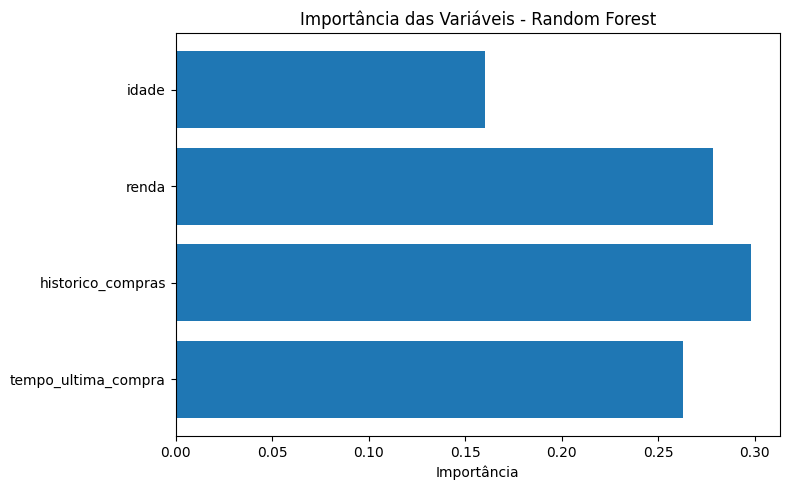

In [10]:
print("="*50)

print("🔍 QUAIS VARIÁVEIS MAIS INFLUENCIARAM?")

print("="*50)



importancias = floresta.feature_importances_

nomes = X.columns



# Ordenar do mais importante para o menos

ordenados = sorted(zip(nomes, importancias), key=lambda x: x[1], reverse=True)



for i, (nome, imp) in enumerate(ordenados):

    print(f"   {i+1}. {nome}: {imp:.3f}")



# Gráfico

plt.figure(figsize=(8, 5))

plt.barh(nomes, importancias)

plt.xlabel("Importância")

plt.title("Importância das Variáveis - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# 10. Atividade: testar mudanças nos hiperparâmetros

## 10.1 Alterando max_depth (Árvore de Decisão)

max_depth=2: acurácia treino=0.7350 | acurácia teste=0.7700
max_depth=3: acurácia treino=0.9000 | acurácia teste=0.8600
max_depth=5: acurácia treino=0.9250 | acurácia teste=0.8750
max_depth=10: acurácia treino=0.9925 | acurácia teste=0.8600
max_depth=None: acurácia treino=1.0000 | acurácia teste=0.8650


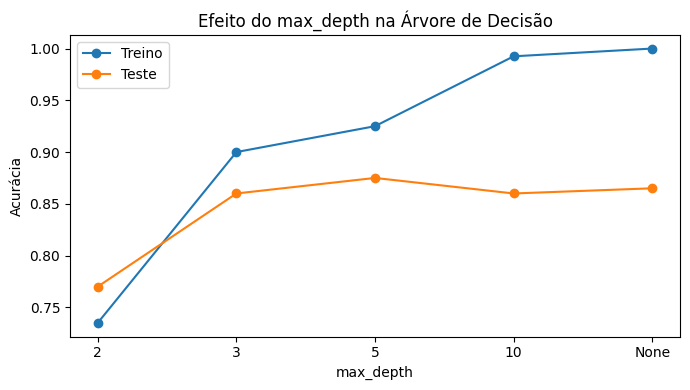

In [11]:
profundidades = [2, 3, 5, 10, None]
resultados_arvore = []

for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_treino, y_treino)
    acc_treino = accuracy_score(y_treino, modelo.predict(X_treino))
    acc_teste = accuracy_score(y_teste, modelo.predict(X_teste))
    resultados_arvore.append((d, acc_treino, acc_teste))
    print(f"max_depth={d}: acurácia treino={acc_treino:.4f} | acurácia teste={acc_teste:.4f}")

profs = [str(p) for p,_,_ in resultados_arvore]
plt.figure(figsize=(7,4))
plt.plot(profs, [r[1] for r in resultados_arvore], marker='o', label='Treino')
plt.plot(profs, [r[2] for r in resultados_arvore], marker='o', label='Teste')
plt.xlabel('max_depth')
plt.ylabel('Acurácia')
plt.title('Efeito do max_depth na Árvore de Decisão')
plt.legend()
plt.tight_layout()
plt.show()

## 10.2 Alterando n_estimators (Random Forest)

n_estimators=10: acurácia teste=0.9100
n_estimators=50: acurácia teste=0.9200
n_estimators=100: acurácia teste=0.9150
n_estimators=200: acurácia teste=0.9150
n_estimators=300: acurácia teste=0.9100


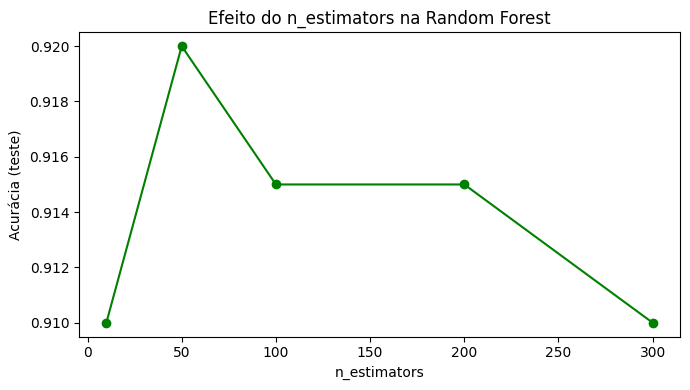

In [12]:
n_arvores = [10, 50, 100, 200, 300]
resultados_floresta = []

for n in n_arvores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42)
    modelo.fit(X_treino, y_treino)
    acc_teste = accuracy_score(y_teste, modelo.predict(X_teste))
    resultados_floresta.append((n, acc_teste))
    print(f"n_estimators={n}: acurácia teste={acc_teste:.4f}")

plt.figure(figsize=(7,4))
plt.plot(n_arvores, [r[1] for r in resultados_floresta], marker='o', color='green')
plt.xlabel('n_estimators')
plt.ylabel('Acurácia (teste)')
plt.title('Efeito do n_estimators na Random Forest')
plt.tight_layout()
plt.show()

# 11. Respostas

**1. Qual modelo teve melhor acurácia? A diferença é grande?**

A **Random Forest** teve melhor acurácia (≈91,5%) do que a Árvore de Decisão isolada (≈87,5%), com a configuração padrão (max_depth=5, n_estimators=100). A diferença é de cerca de 4 pontos percentuais — não é enorme, mas é consistente, porque a floresta combina várias árvores e reduz o overfitting de uma árvore única.

**2. O que aconteceu quando você aumentou a profundidade da árvore?**

Com max_depth pequeno (2 ou 3), a acurácia de treino e teste eram parecidas, mas baixas (underfitting — o modelo é simples demais). Conforme aumentamos a profundidade (5, 10, None/sem limite), a acurácia de **treino** subiu até quase 100%, mas a acurácia de **teste** parou de melhorar e até caiu um pouco depois de certo ponto (melhor resultado por volta de max_depth=5). Isso é um sinal claro de **overfitting**: a árvore decorou os dados de treino em vez de generalizar.

**3. Para este problema, qual modelo você escolheria e por quê?**

Escolheria a **Random Forest**, pois apresentou acurácia mais alta e mais estável (variando pouco entre diferentes valores de n_estimators), além de ser mais robusta a overfitting do que uma única Árvore de Decisão. A Árvore de Decisão só seria preferível se a interpretabilidade (visualizar as regras de decisão) fosse mais importante que a performance.